In [1]:
import numpy as np
from sympy import lambdify,diff,exp,latex
from sympy.abc import x,y
import matplotlib.pyplot as plt

In [2]:
num = 301
x_array = np.linspace(-3,3,num)
y_array = np.linspace(-3,3,num)
xx,yy = np.meshgrid(x_array,y_array)

In [3]:
f_xy = 3 * (1 - x)**2 * exp(-x**2 - (y + 1)**2) \
    - 10 * (x / 5 - x**3 - y**5) * exp(-x**2 - y**2) \
    - 1/3 * exp(-(x + 1)**2 - y**2)
f_xy

3*(1 - x)**2*exp(-x**2 - (y + 1)**2) - (-10*x**3 + 2*x - 10*y**5)*exp(-x**2 - y**2) - 0.333333333333333*exp(-y**2 - (x + 1)**2)

In [4]:
f_xy_fcn = lambdify((x,y),f_xy)
f_xy_zz = f_xy_fcn(xx,yy)

In [5]:
df_dx = f_xy.diff(x)
df_dx

-6*x*(1 - x)**2*exp(-x**2 - (y + 1)**2) + 2*x*(-10*x**3 + 2*x - 10*y**5)*exp(-x**2 - y**2) - (2 - 30*x**2)*exp(-x**2 - y**2) - 0.333333333333333*(-2*x - 2)*exp(-y**2 - (x + 1)**2) + 3*(2*x - 2)*exp(-x**2 - (y + 1)**2)

In [6]:
df_dx_fcn = lambdify((x,y),df_dx)
df_dx_zz = df_dx_fcn(xx,yy)

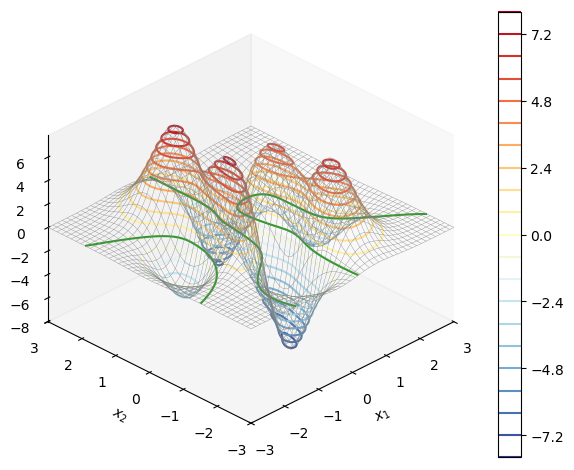

In [15]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,df_dx_zz,color = '0.5',lw = 0.25)
colorbar = ax.contour(xx,yy,df_dx_zz,20,cmap = 'RdYlBu_r')

ax.contour(xx,yy,df_dx_zz,levels = [0],colors = '#339933',linestyles = '-')

fig.colorbar(colorbar,ax = ax)
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f_{x1}(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 紧凑布局
ax.set_xlim(xx.min(), xx.max())  # 设置 x 轴范围
ax.set_ylim(yy.min(), yy.max())  # 设置 y 轴范围
ax.view_init(azim=-135, elev=30)  # 设置视角
ax.grid(False)  # 关闭网格线
plt.show()  # 显示图像

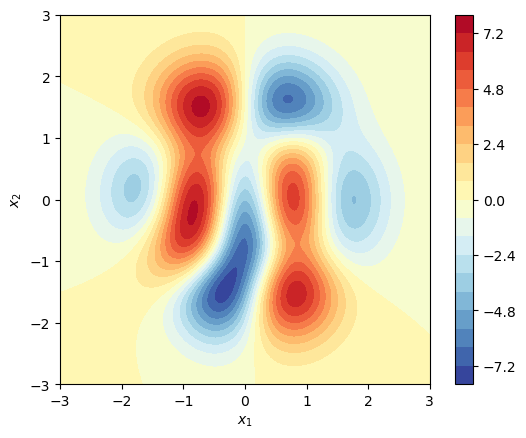

In [19]:
fig,ax = plt.subplots()

colorbar = ax.contourf(xx,yy,df_dx_zz,20,cmap='RdYlBu_r')

fig.colorbar(colorbar,ax = ax)
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal',adjustable = 'box')
plt.show()